In [268]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, confusion_matrix
from sklearn.preprocessing import StandardScaler

data = pd.read_csv("data.csv", index_col="id")
data = data.loc[:,~data.columns.str.contains("Unnamed")]

In [264]:
data.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
id,,,,,,,,,,,,,,,,,,,,,
842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [265]:
print(data.shape)
data.describe()

(569, 31)


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


Посмотрим на распределение классов:

<Axes: xlabel='diagnosis', ylabel='Count'>

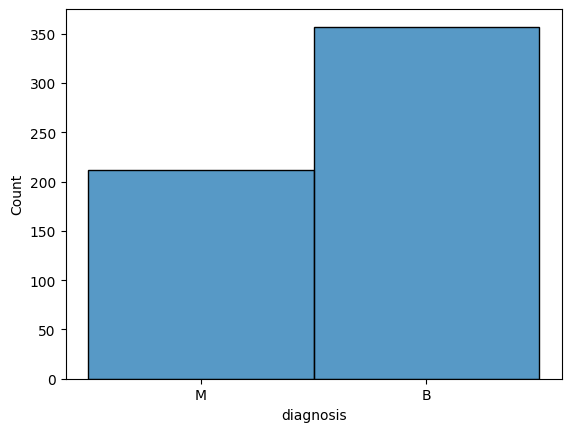

In [267]:
sns.histplot(data["diagnosis"])

Необходимо рассчитать какие параметры коррелируют между собой. Затем посмотрим на распределение этих параметров с учетом диагноза.

<Axes: >

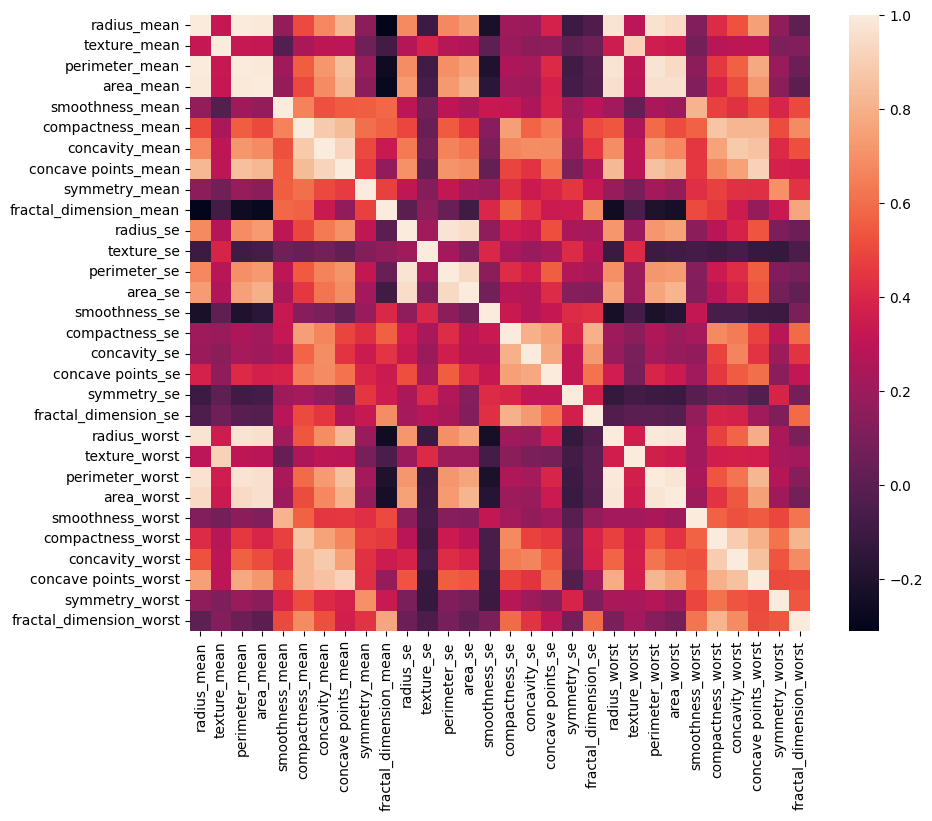

In [ ]:
correlation_threshold = .85 # Значение корреляции, которые мы считаем сильным

correlated_columns = dict() # Колонки, которые коррелируют между собой

corr_data = data.iloc[:,1:].corr() # Игнорируем первый столбец с диагнозом

for column in corr_data.columns:
    values_bigger_than_threshold = corr_data[column][corr_data[column] > correlation_threshold]
    correlated_columns[column] = list(values_bigger_than_threshold.index)
    correlated_columns[column].remove(column)
    
plt.figure(figsize=(10, 8))
sns.heatmap(corr_data)

Из температурной карты мы видим, что есть коррелирующие между собой поля.

Продолжим изучение и соберем попарные графики

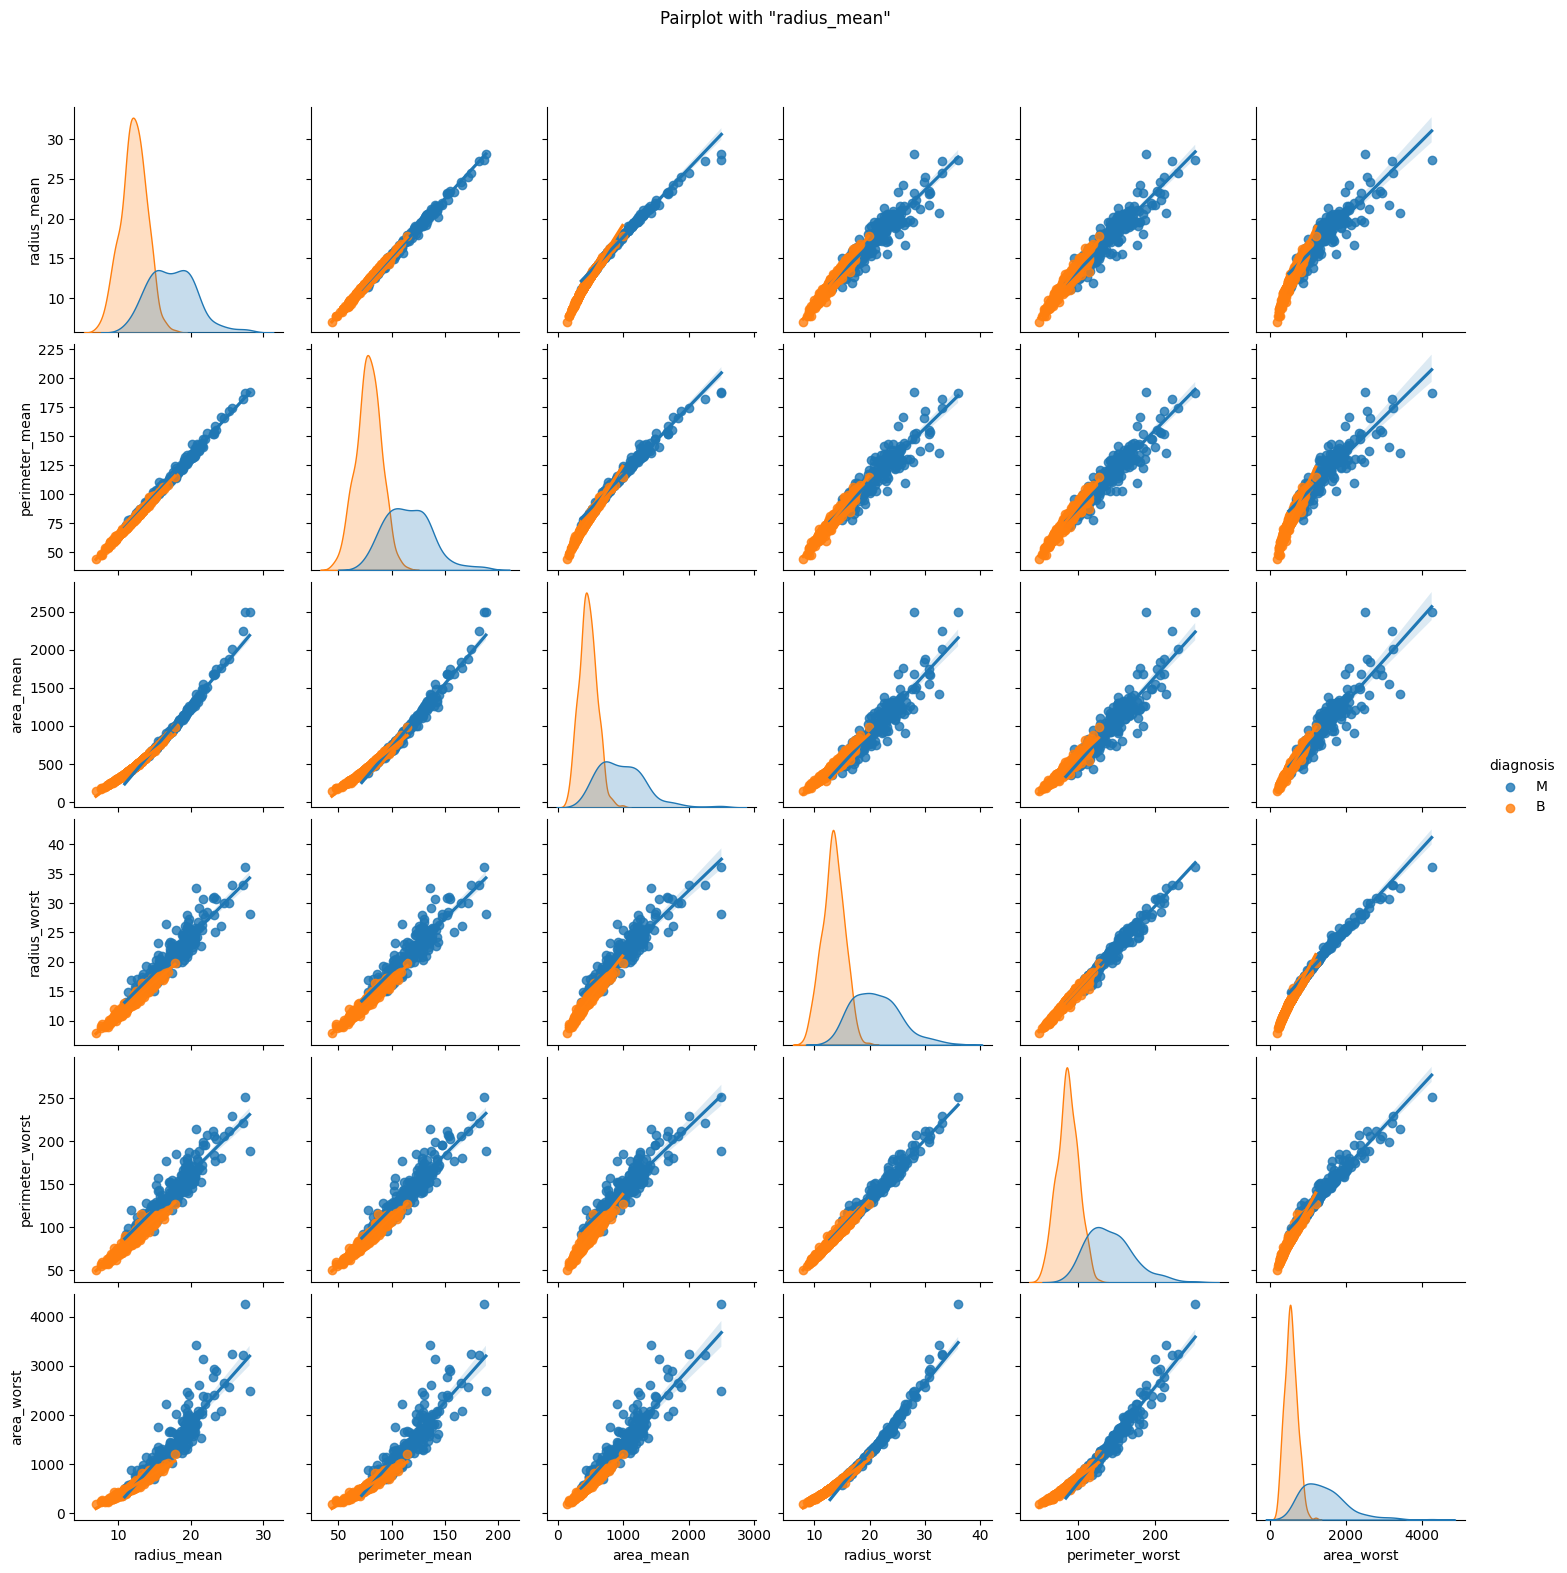

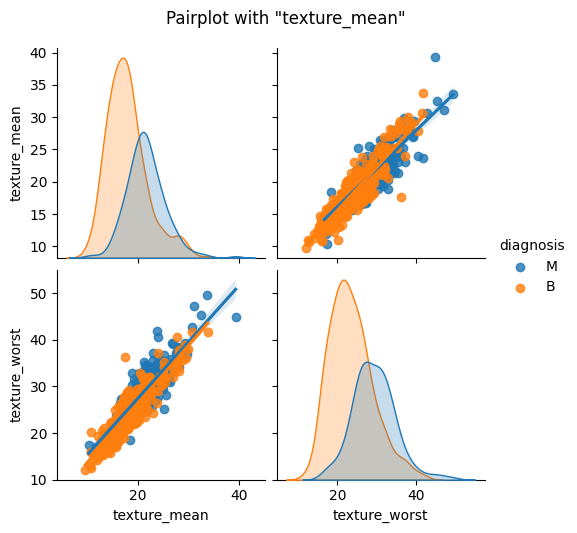

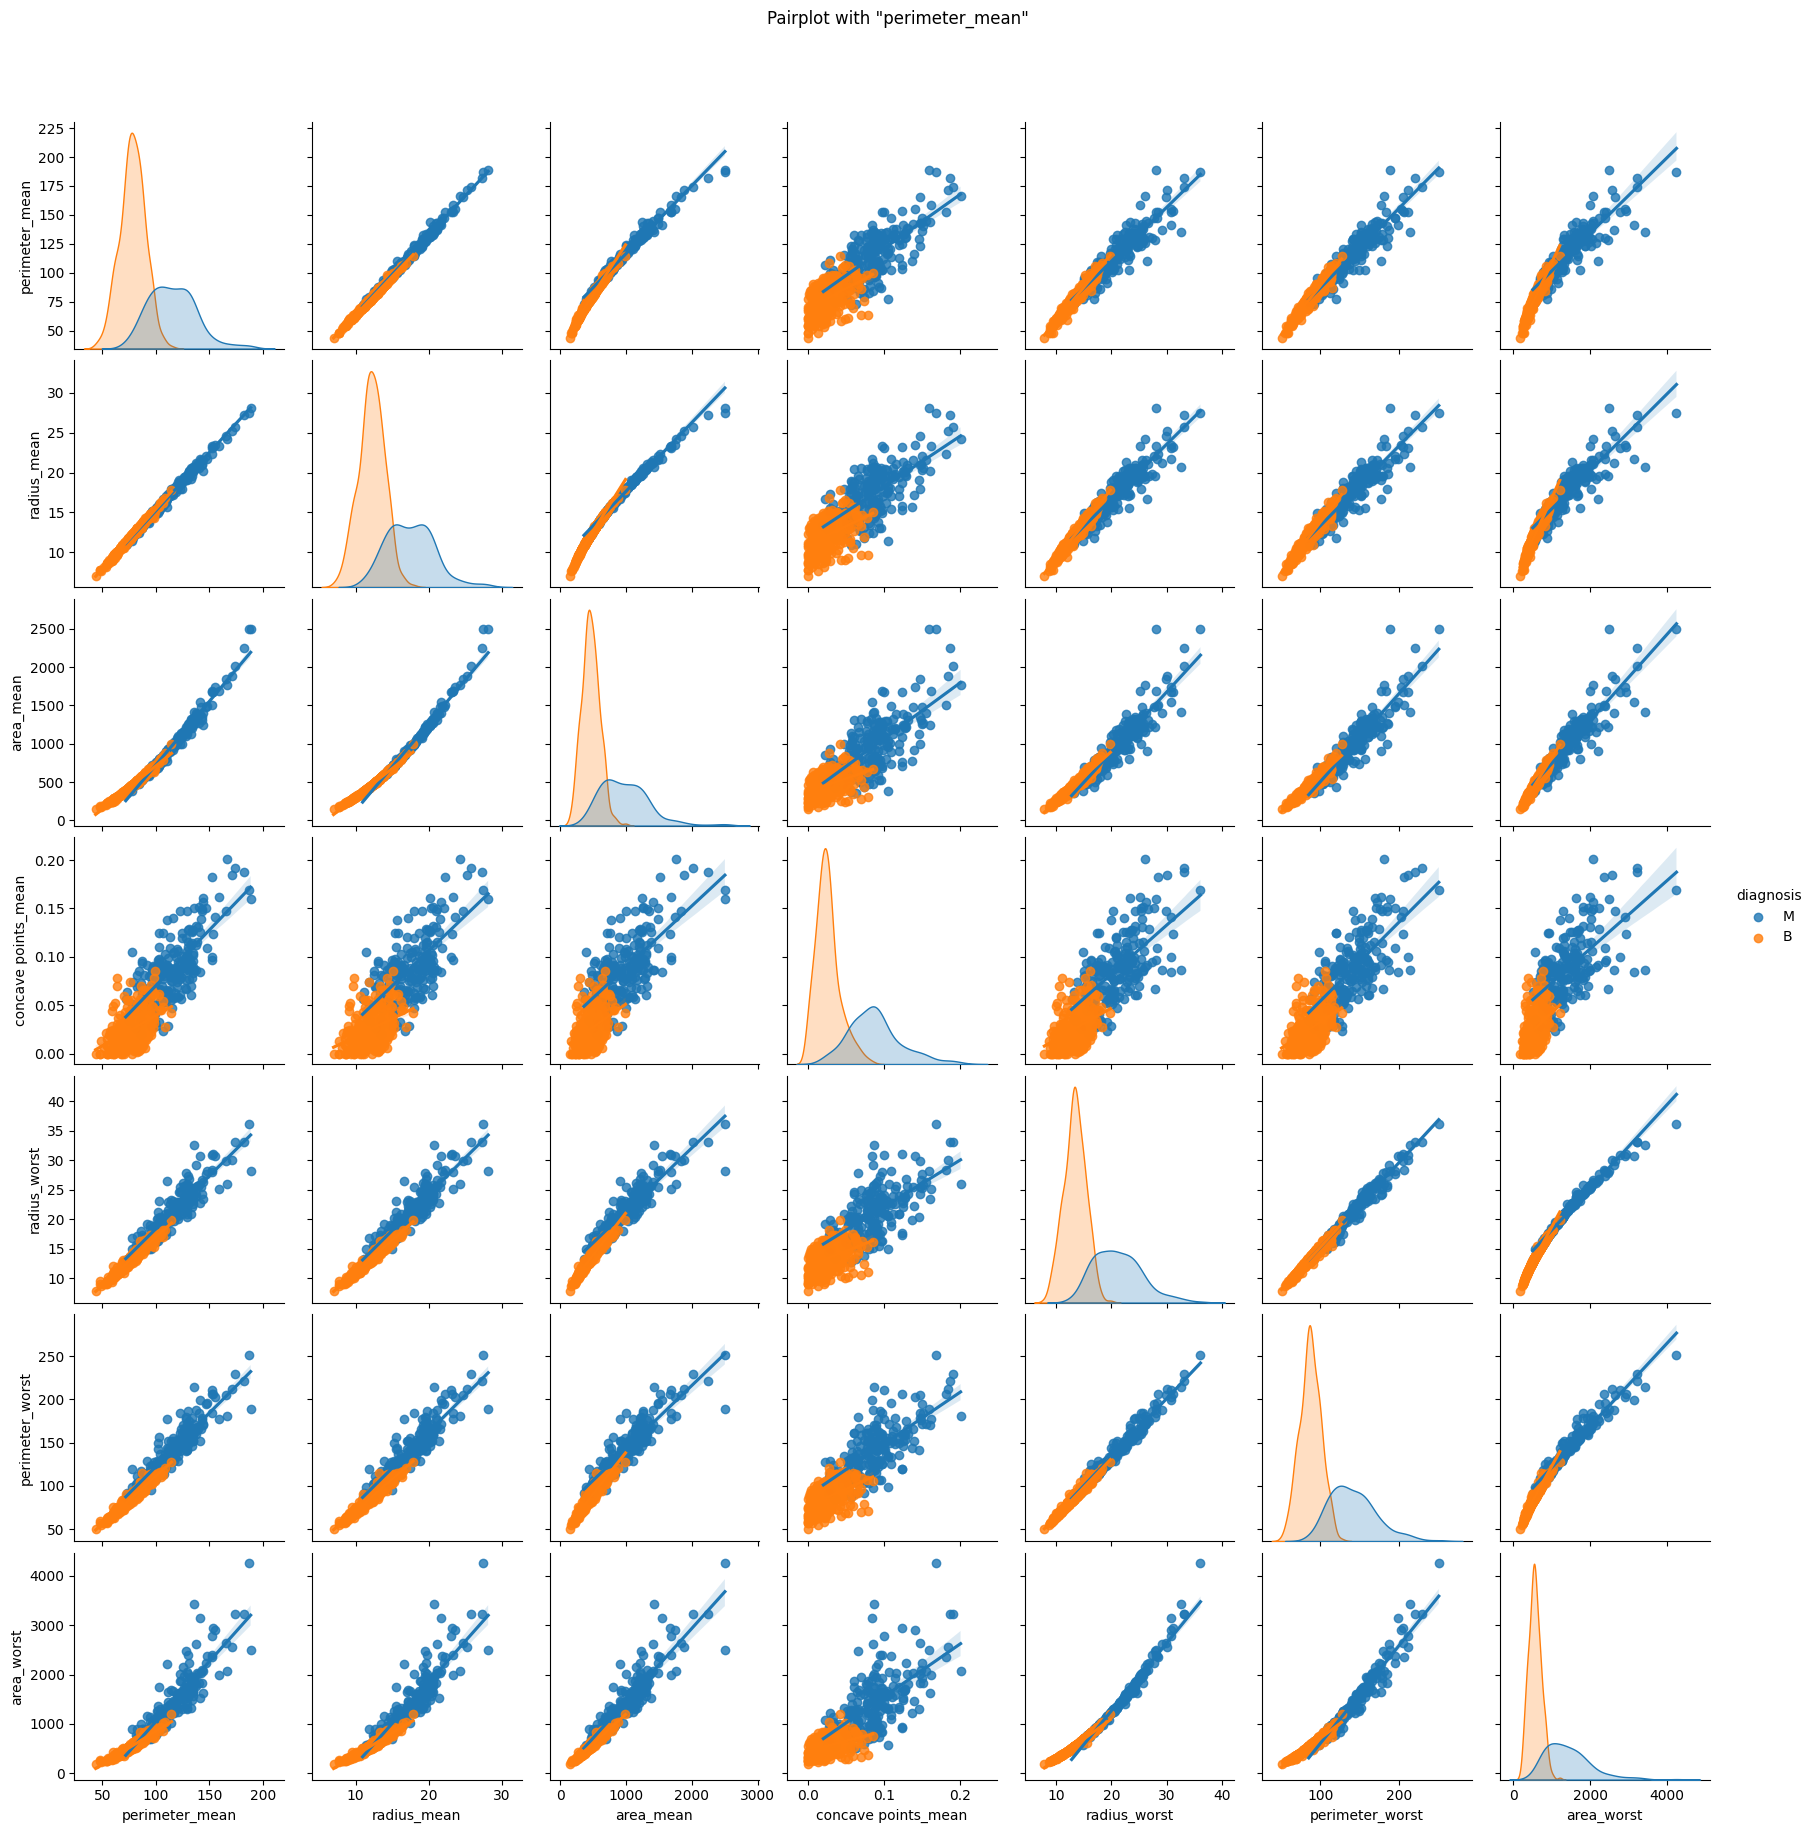

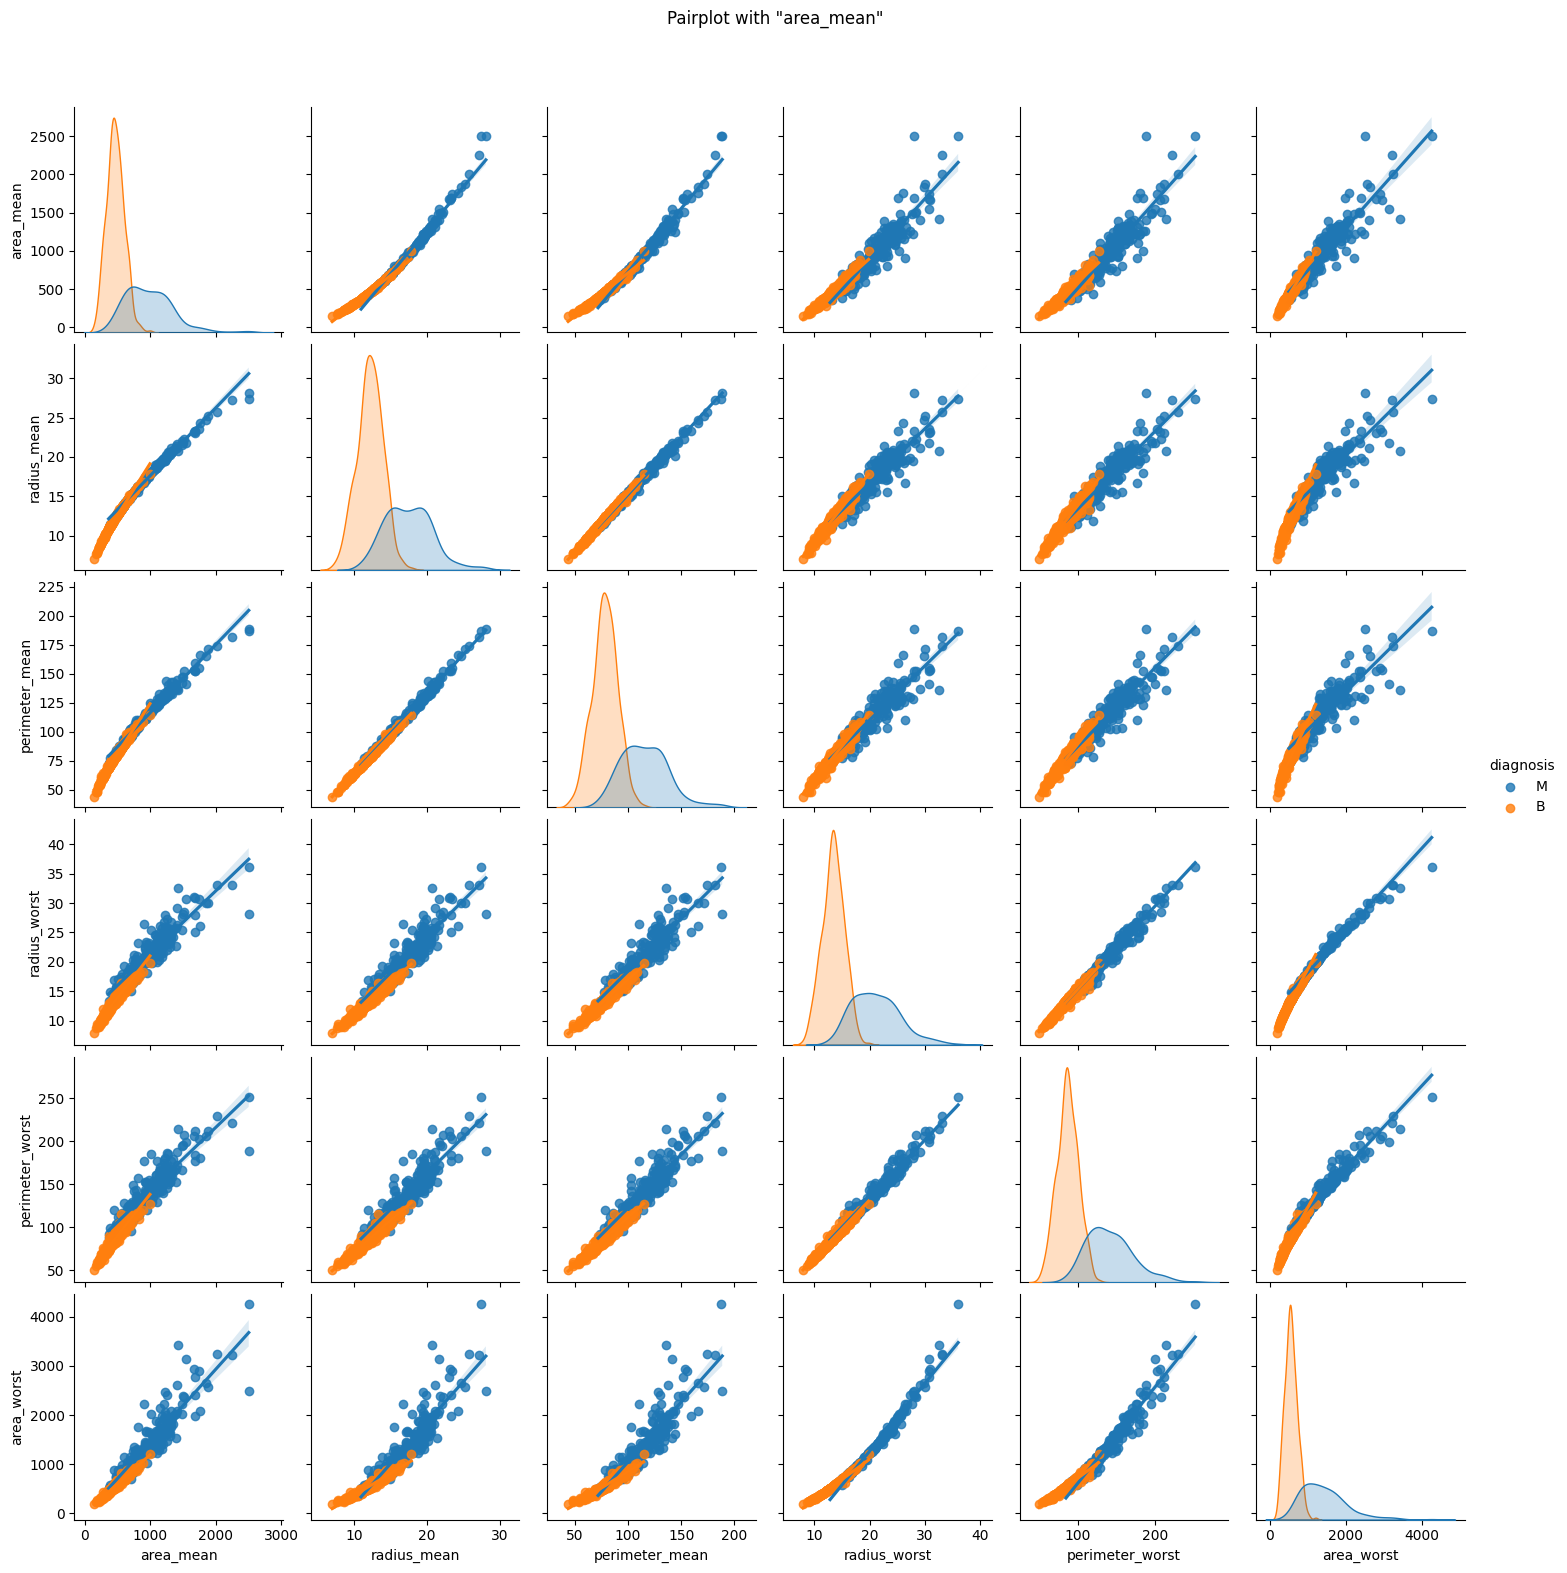

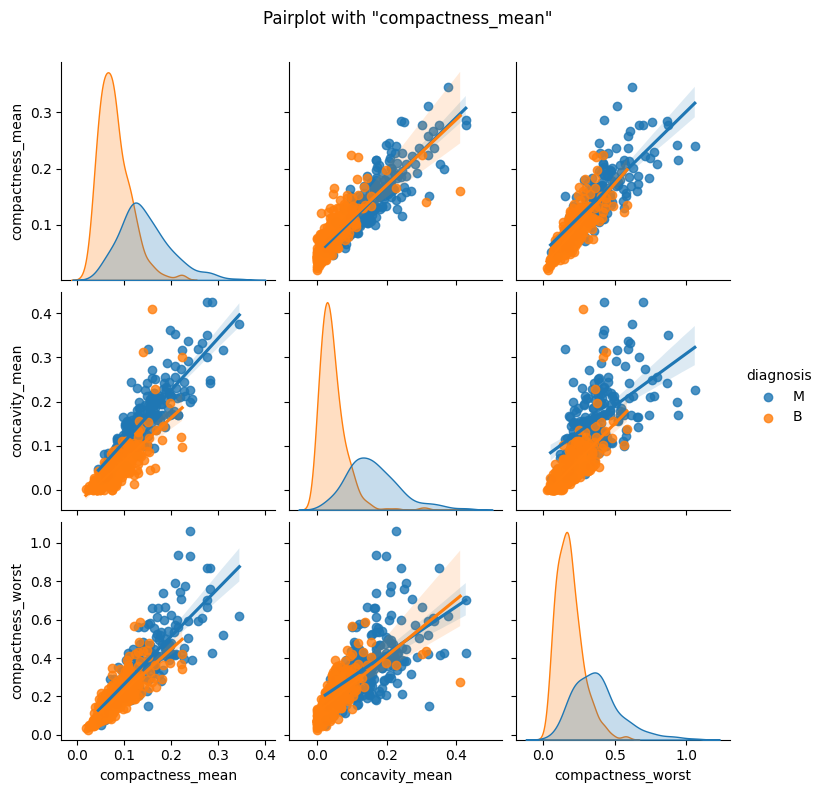

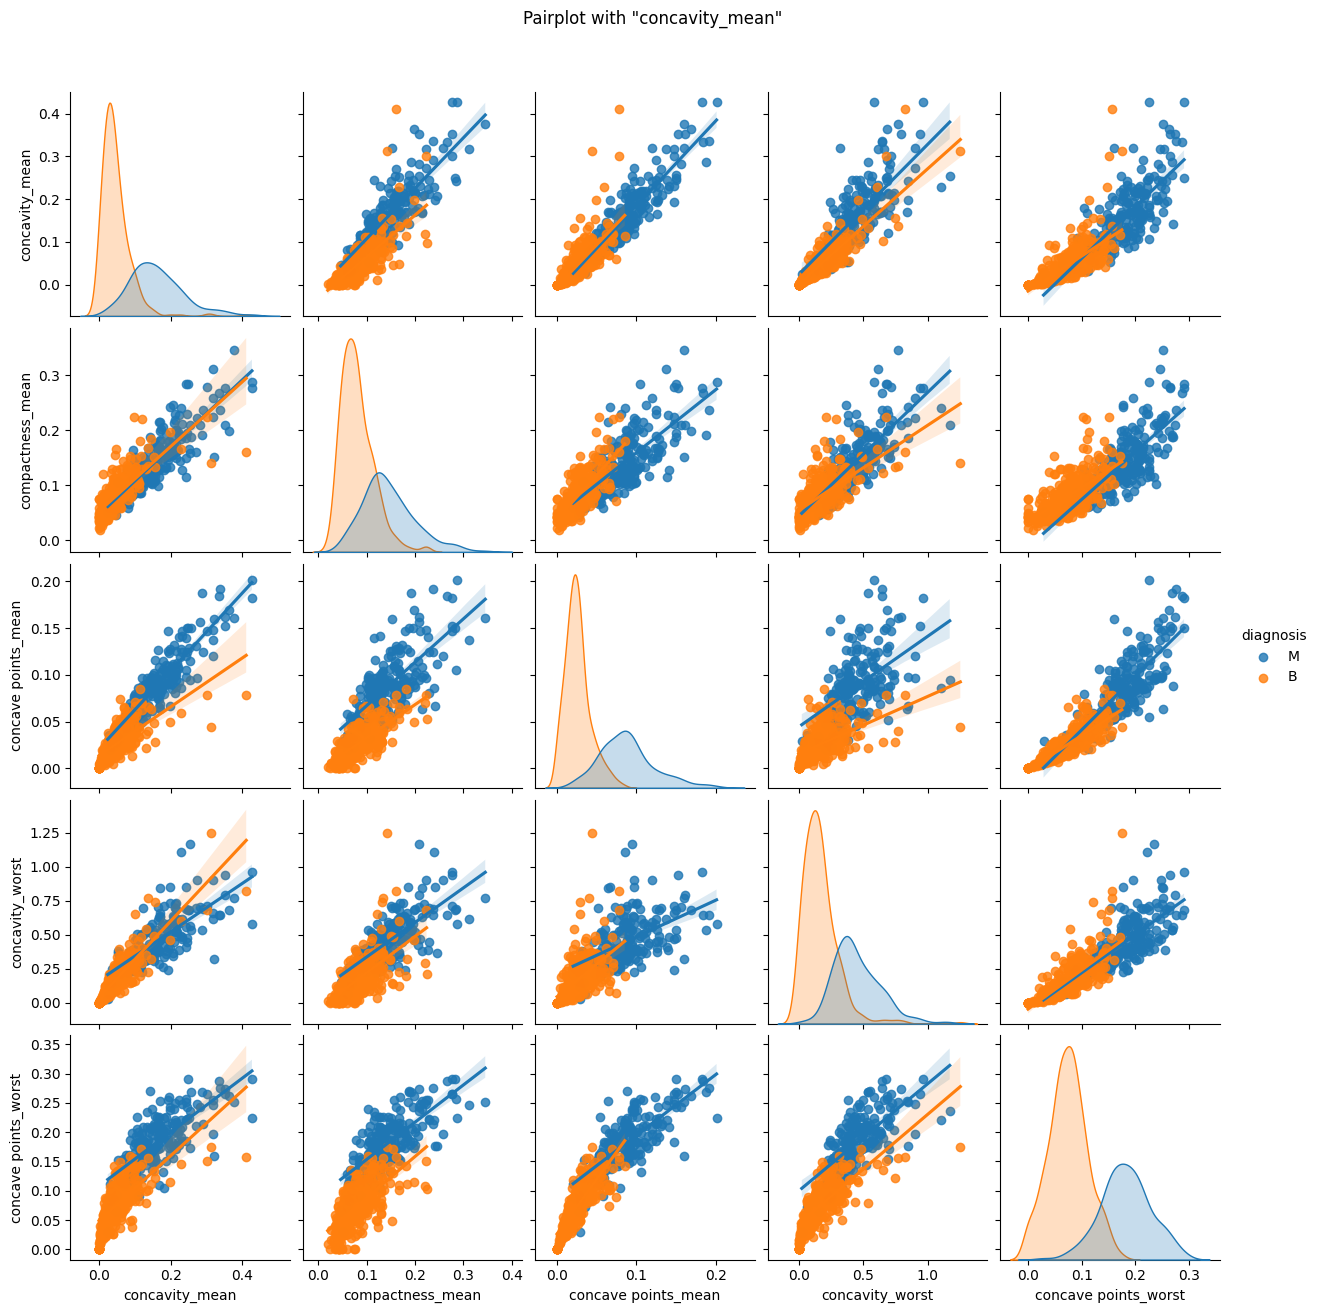

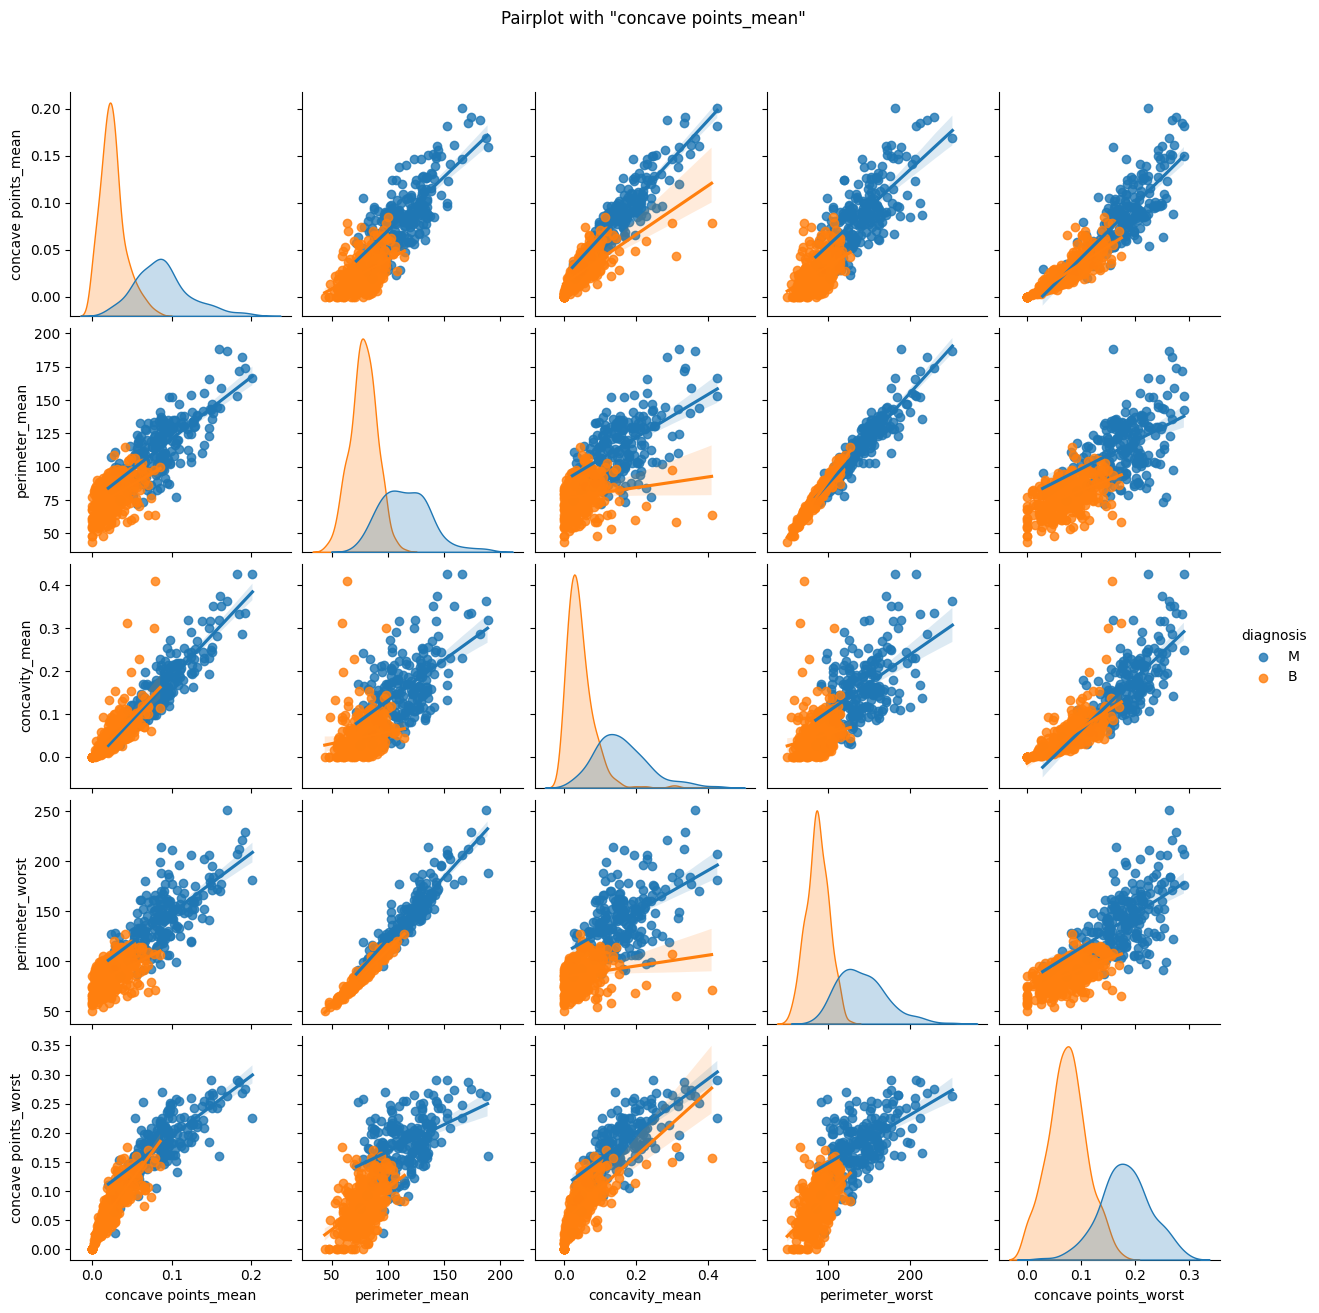

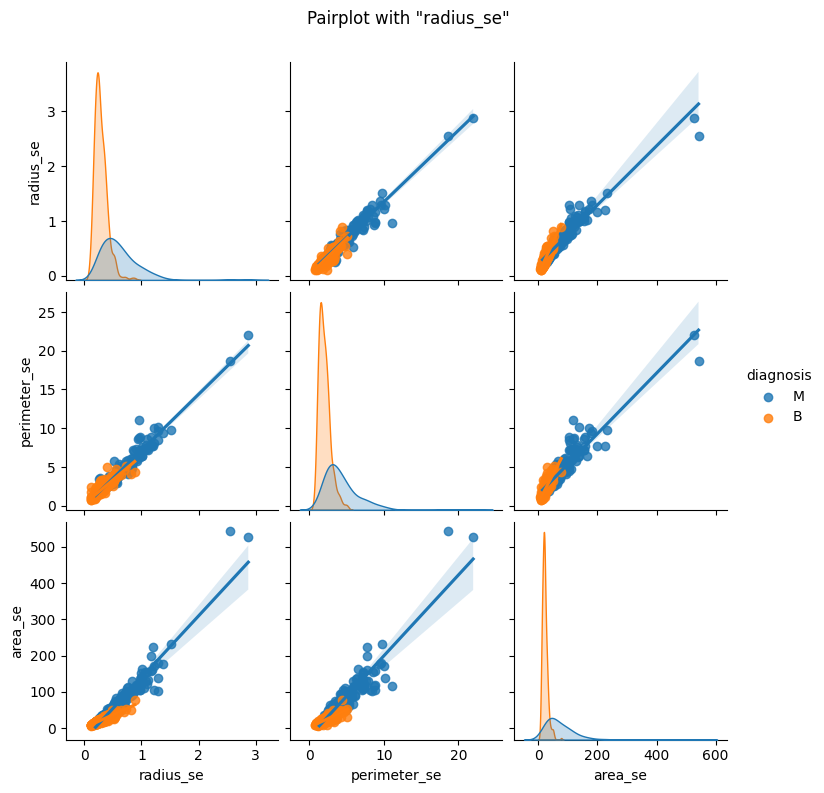

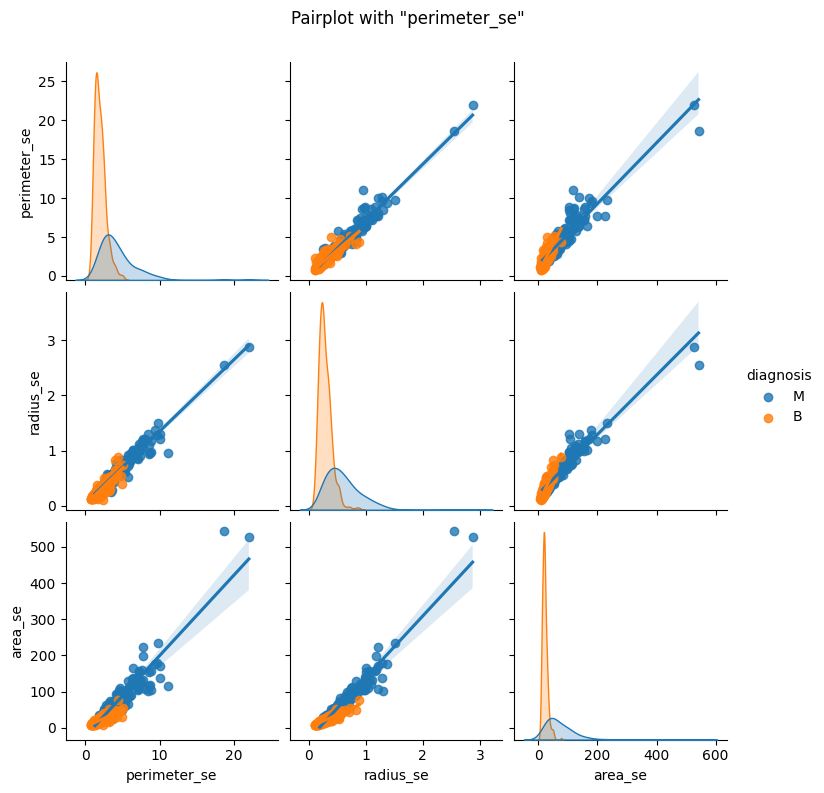

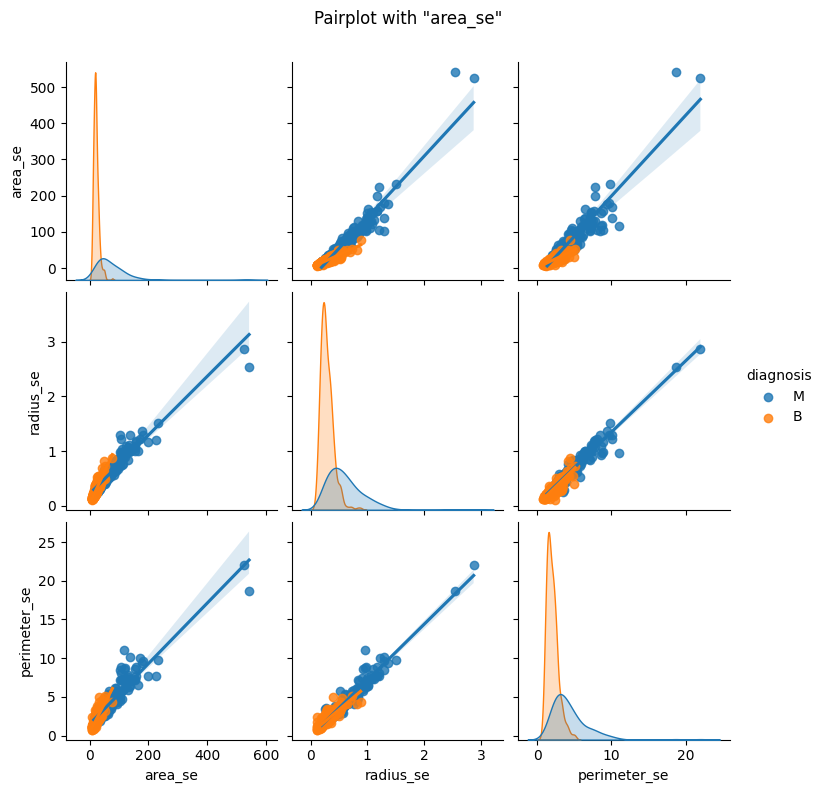

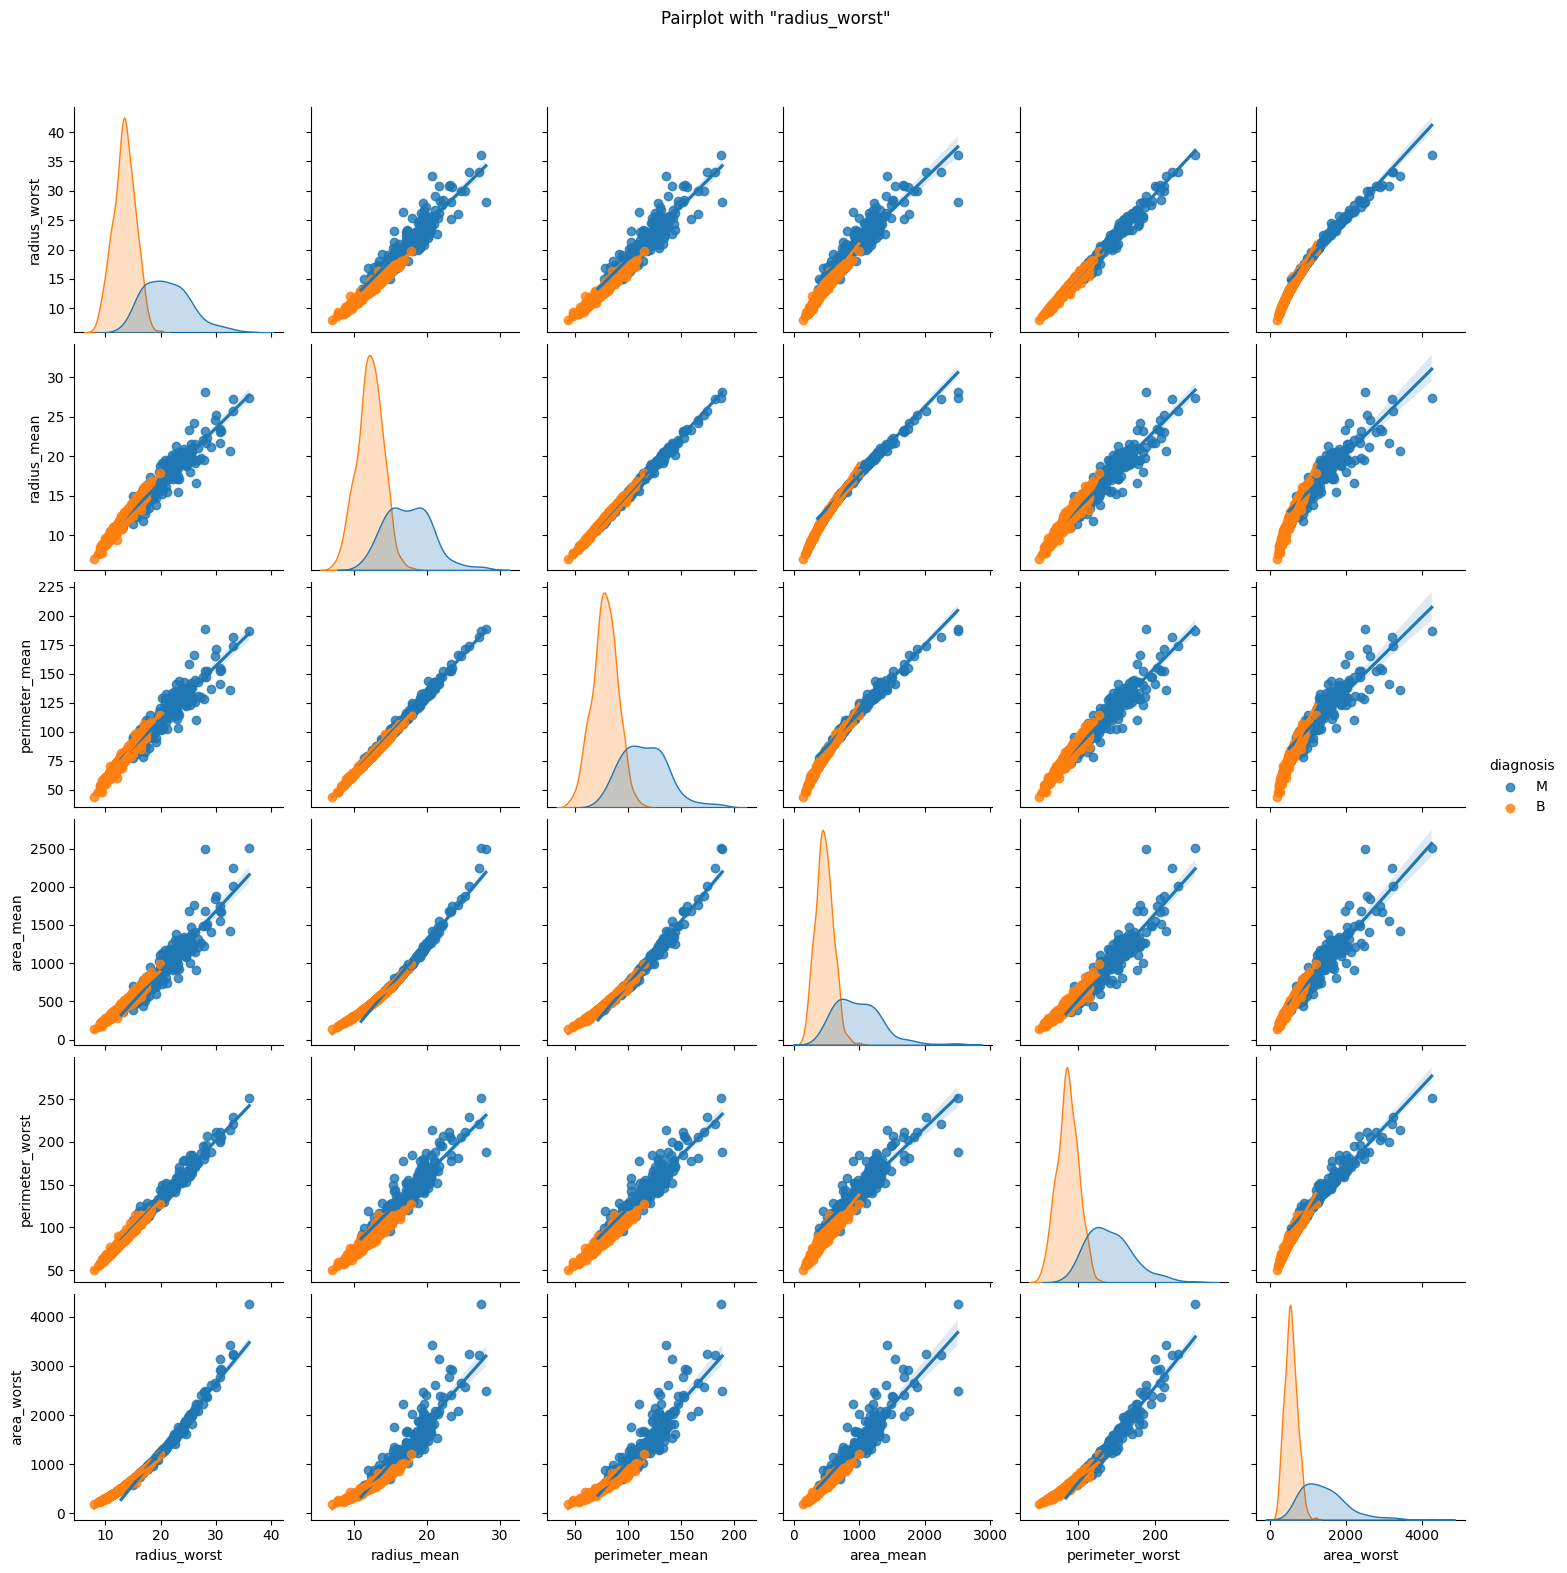

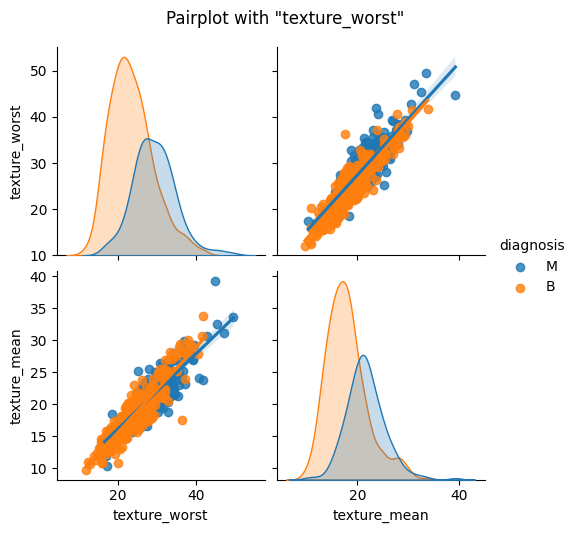

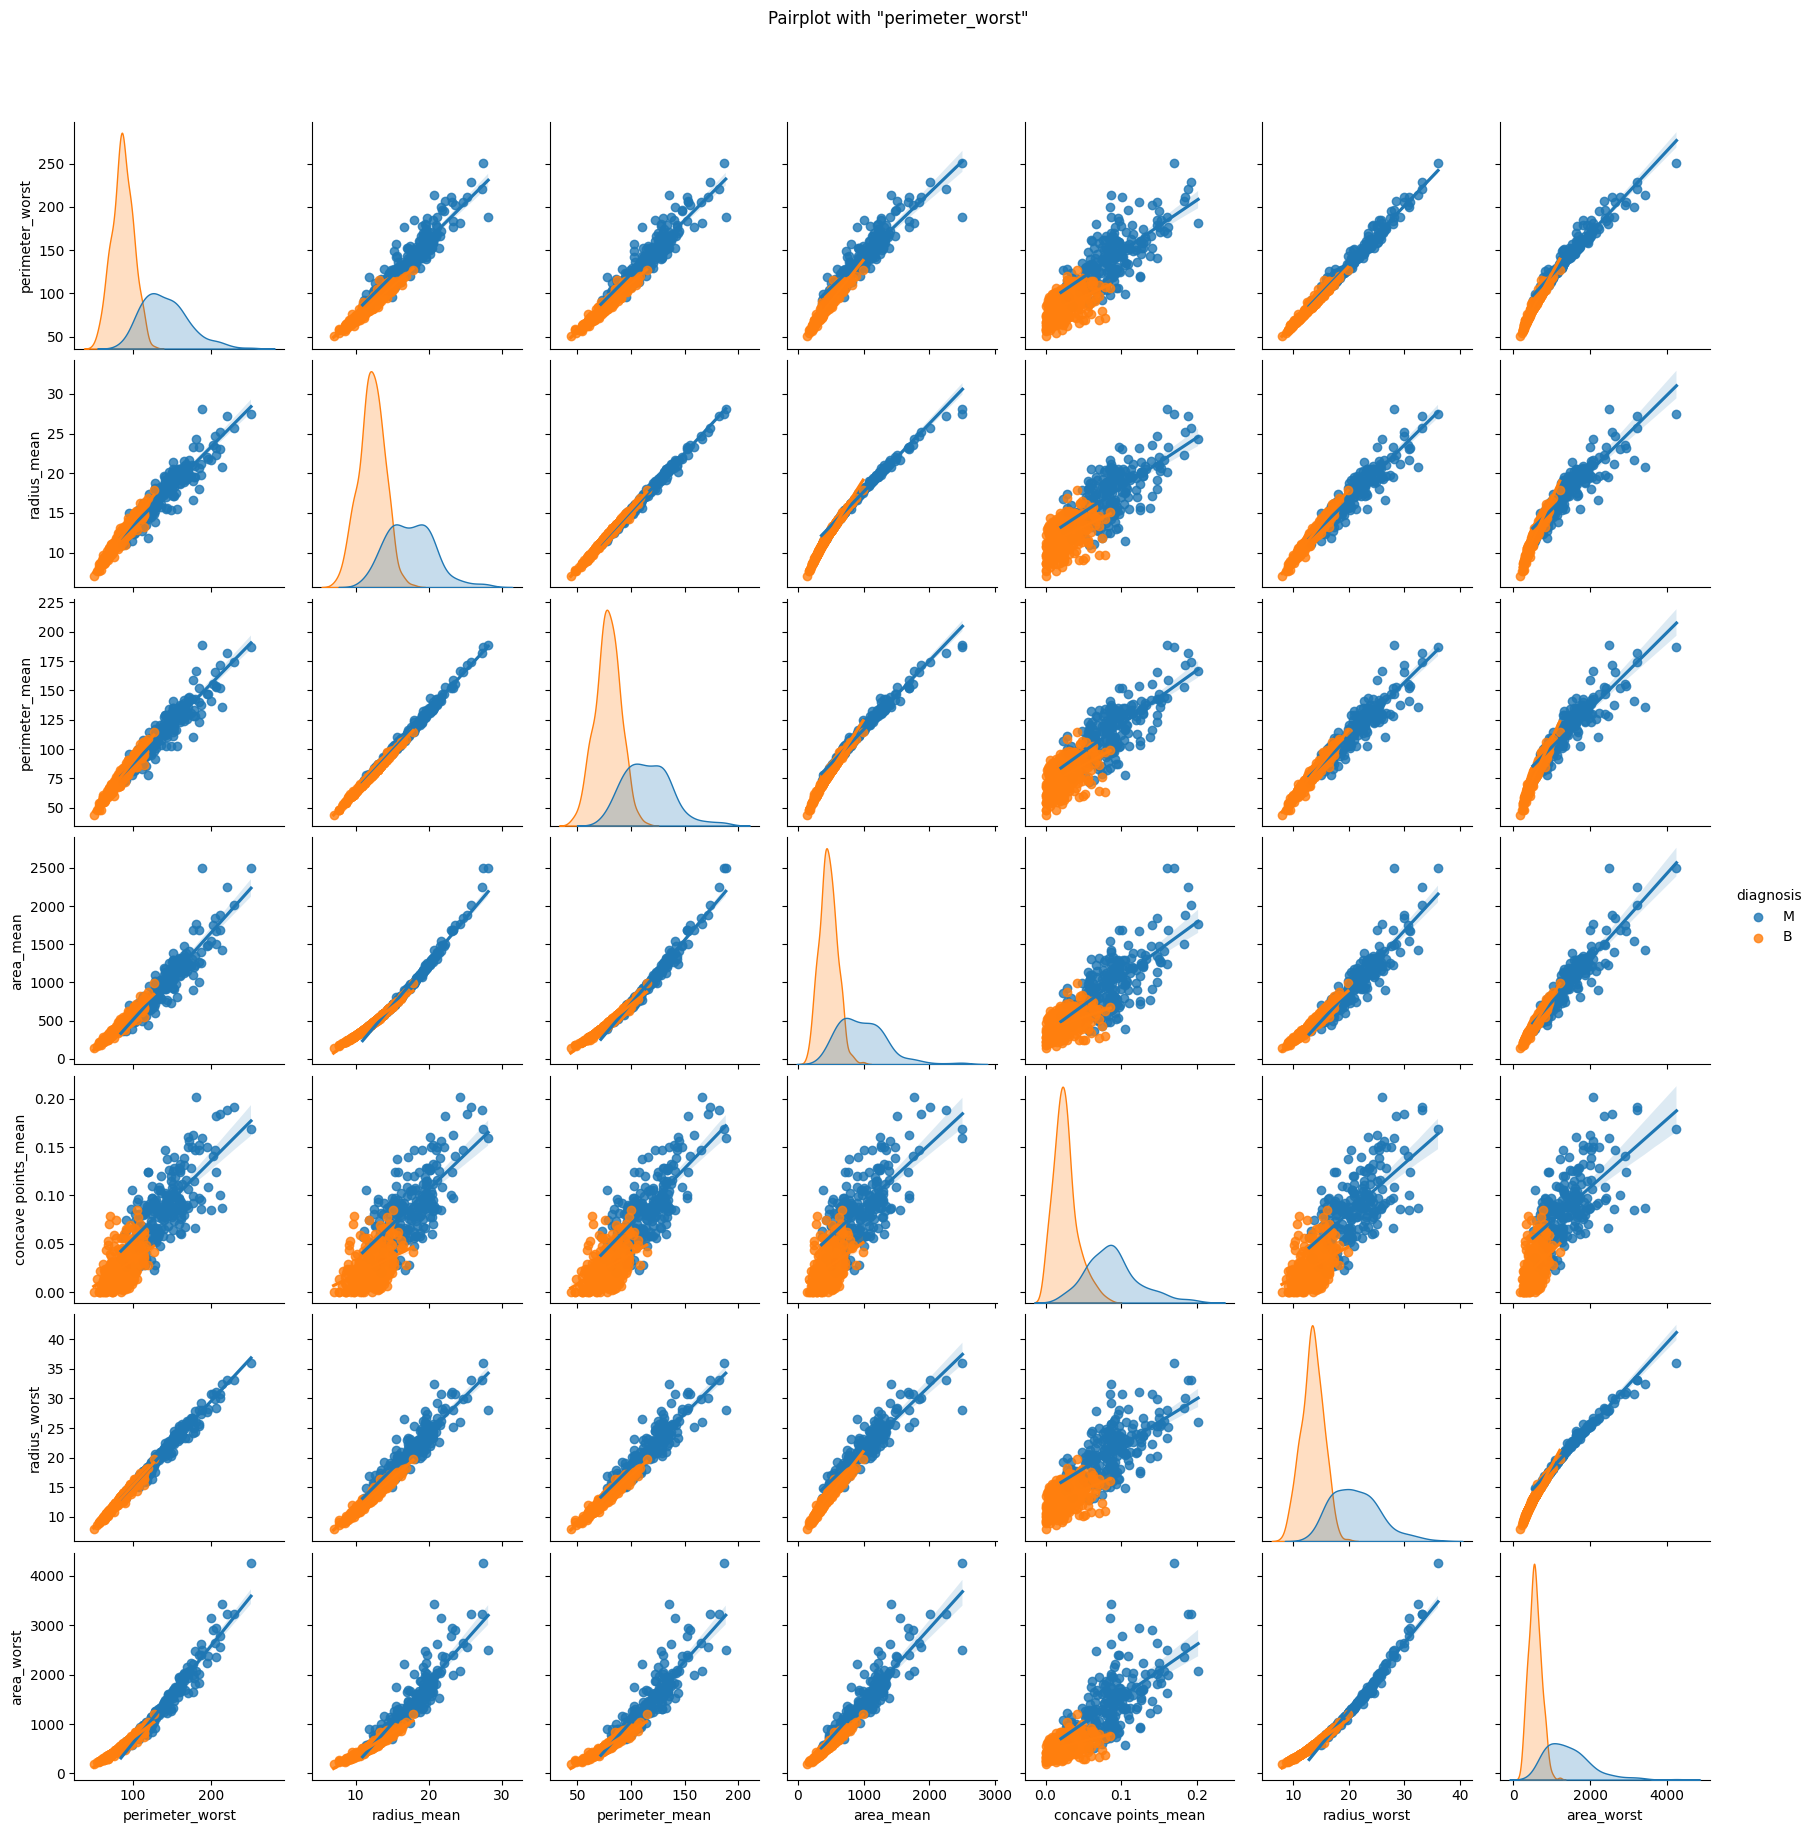

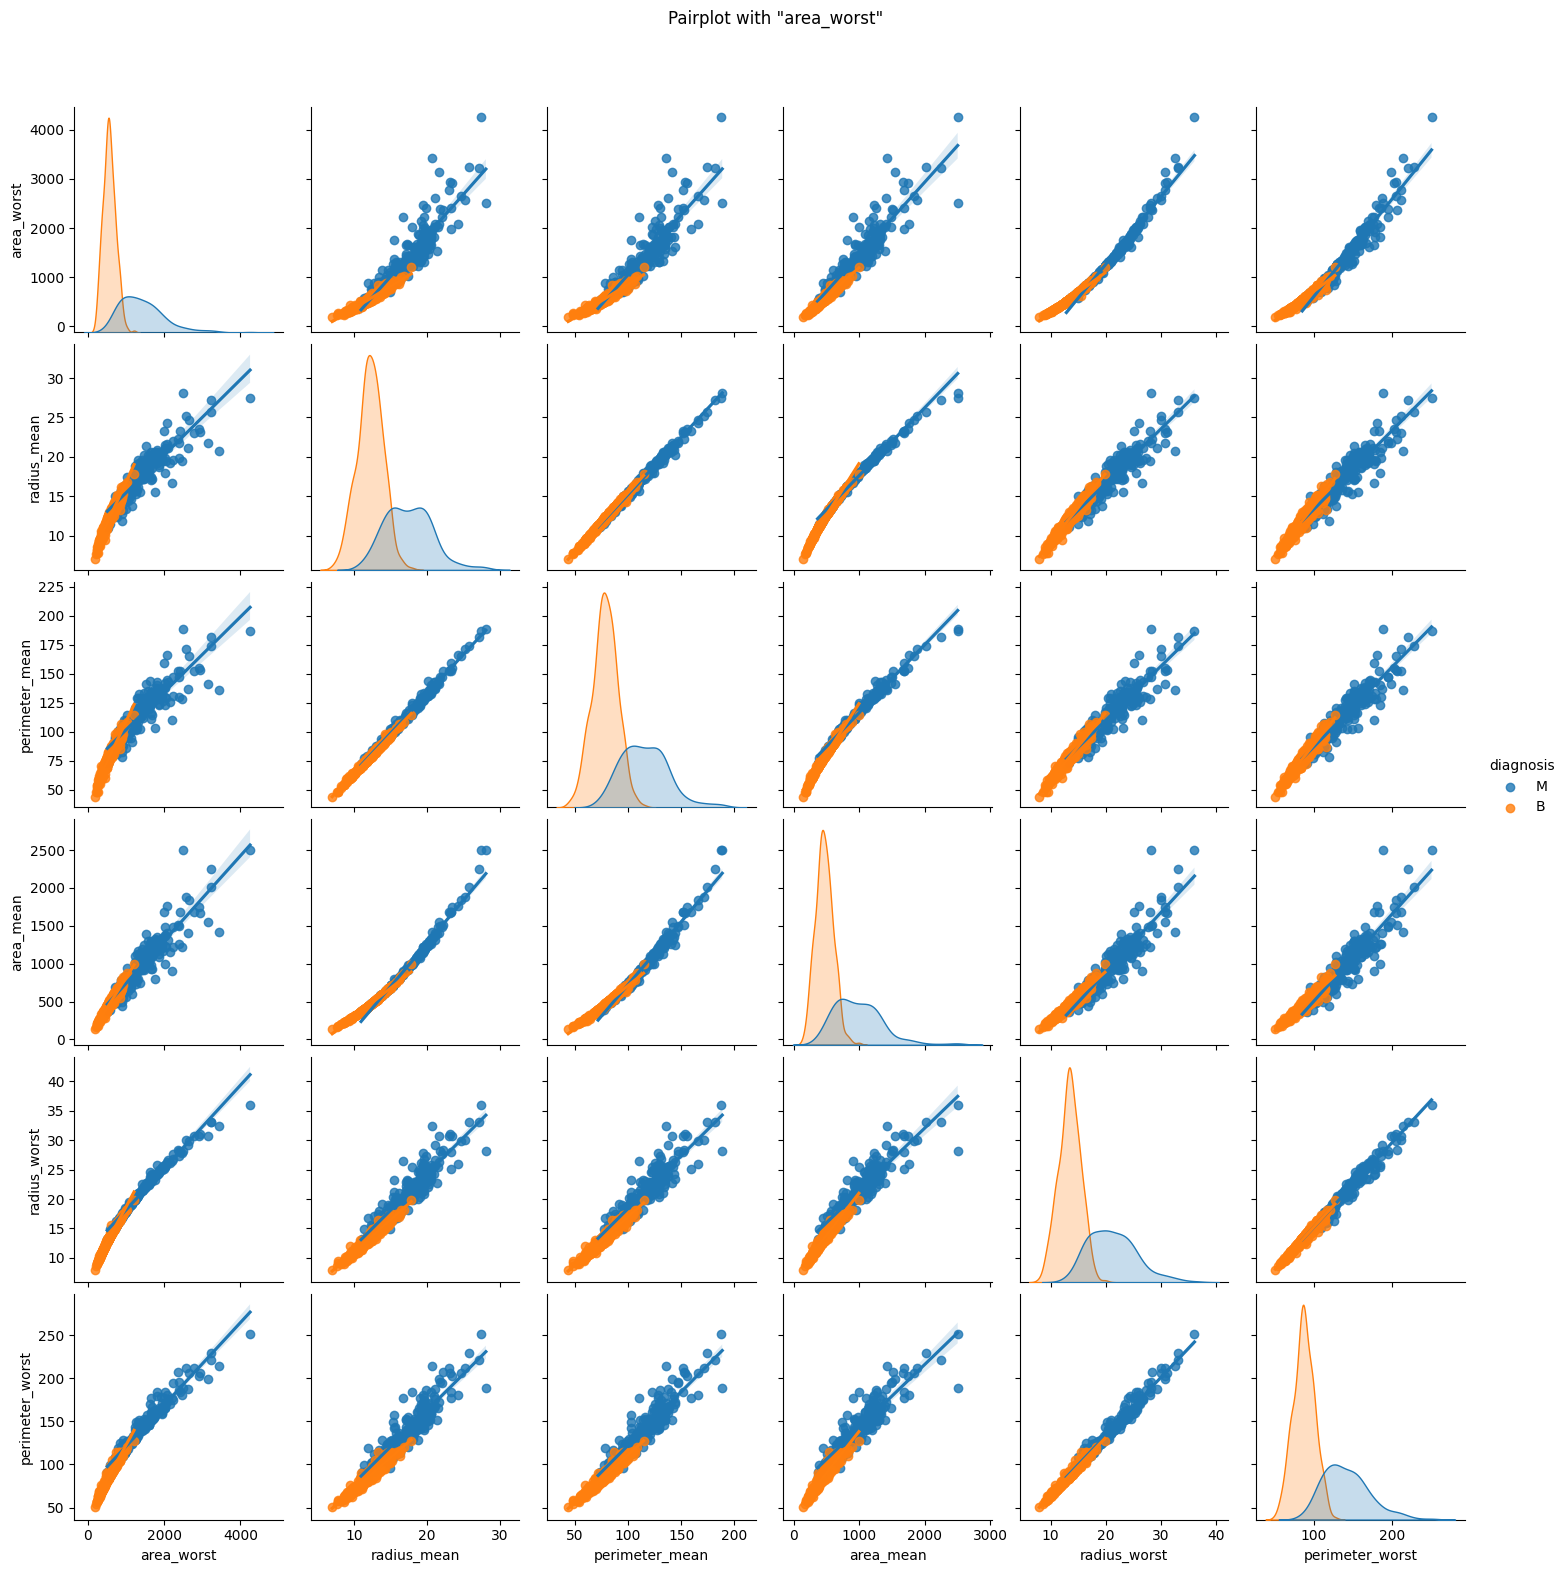

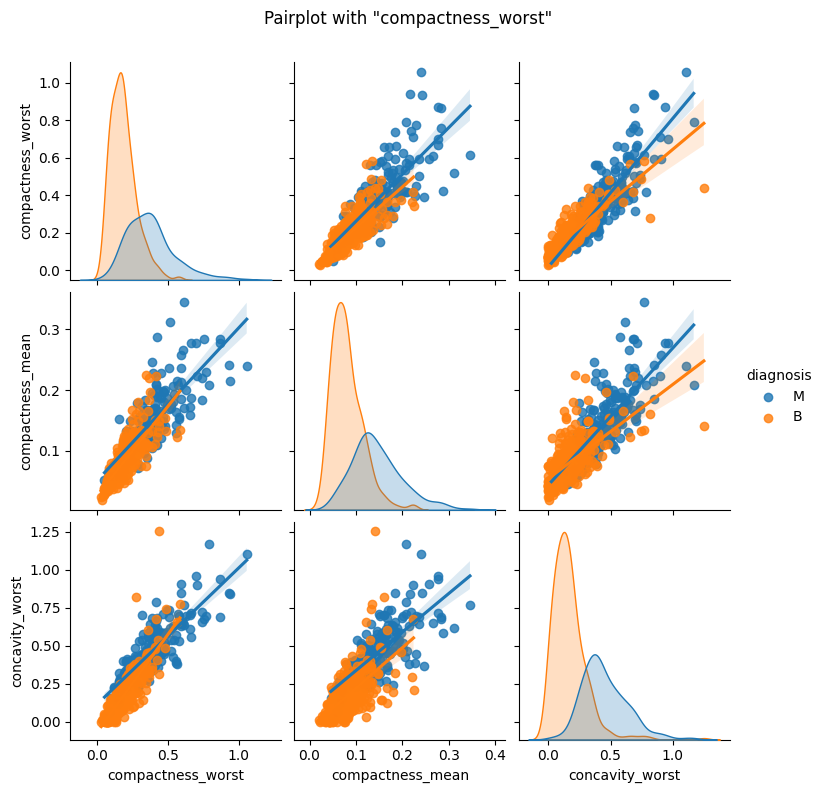

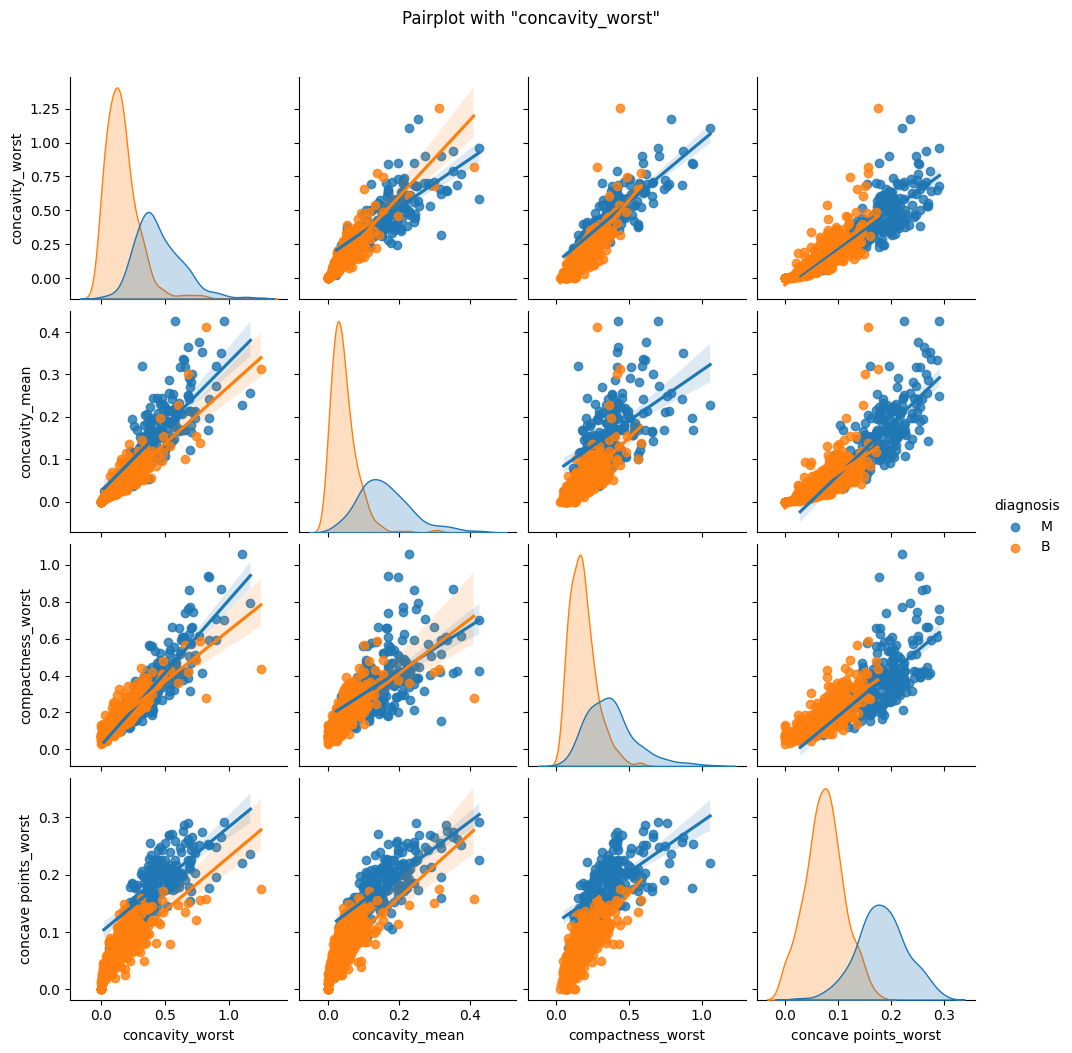

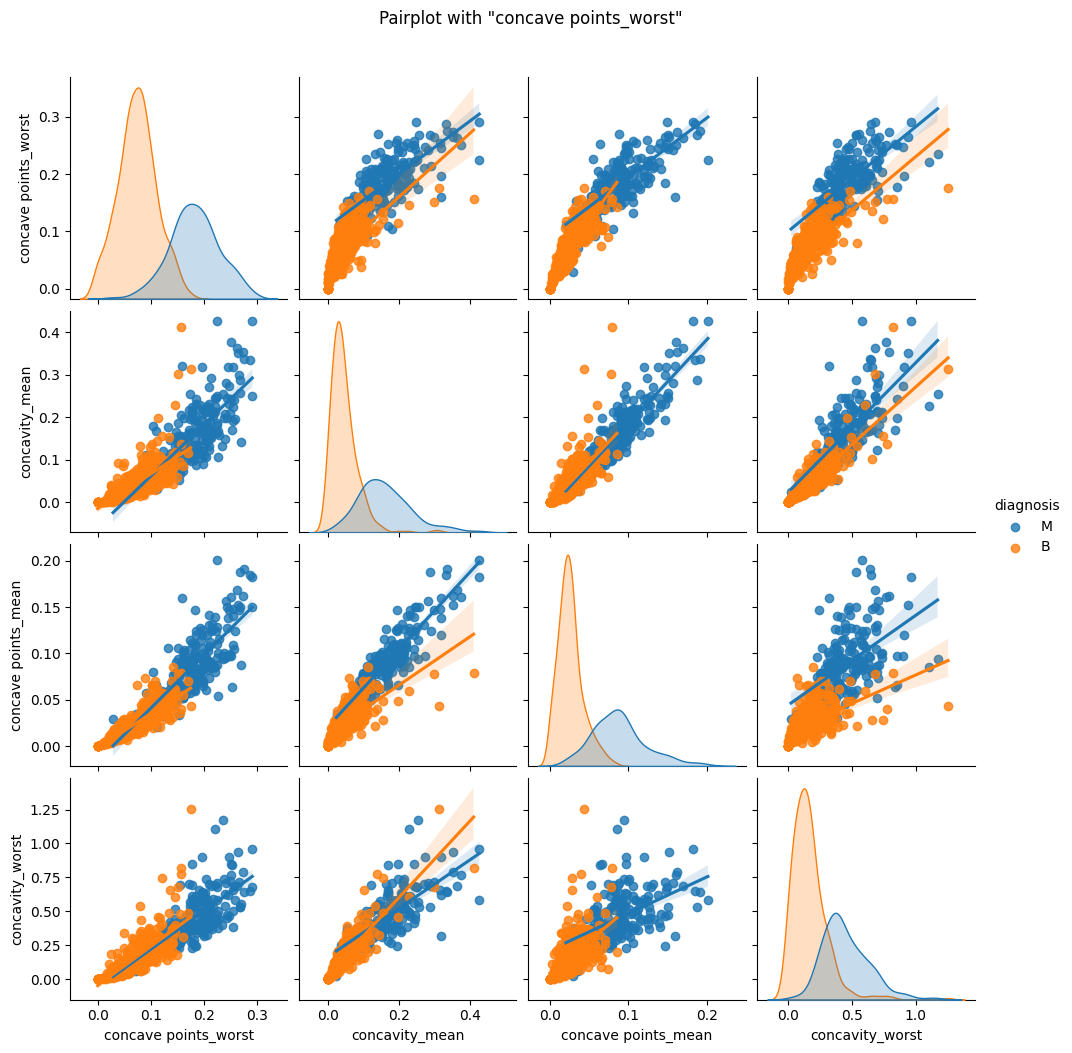

In [75]:
for column in correlated_columns.keys():
    pairplot_columns = [column]
    pairplot_columns.extend(correlated_columns[column])
    if len(pairplot_columns) == 1:
        continue
    pairplot_columns.append("diagnosis")
    sns.pairplot(data[pairplot_columns], hue="diagnosis", kind="reg").figure.suptitle(f'Pairplot with "{column}"', y=1.05)
    plt.show()

Из представленых выше графиков можно сделать вывод, что данные чем больше значения параметров тем больше шанс на развитие злокачественной опухоли. При этом не все параметры стоит учитывать.

Например параметры texture имеют между собой связь, но они размазаны вдоль оси относительно равнмерно и предсказания по данным параметрам возможно будут неточны.

Так же из графиков мы видим, что колонки se и worst полностью коррелируют с средними значениями.

Построим boxplot по средним параметрам.

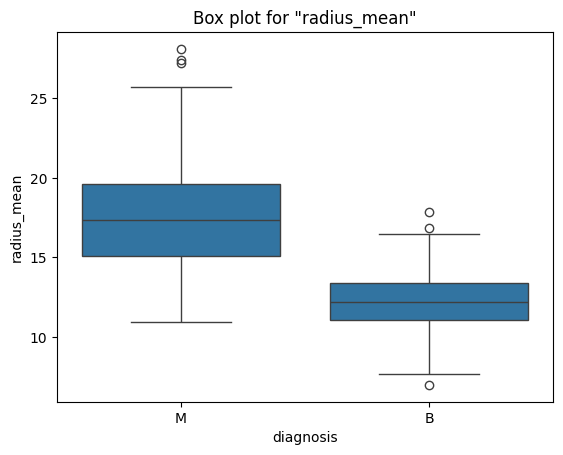

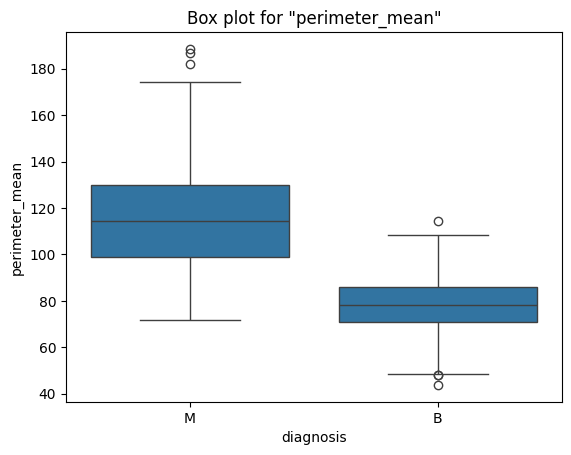

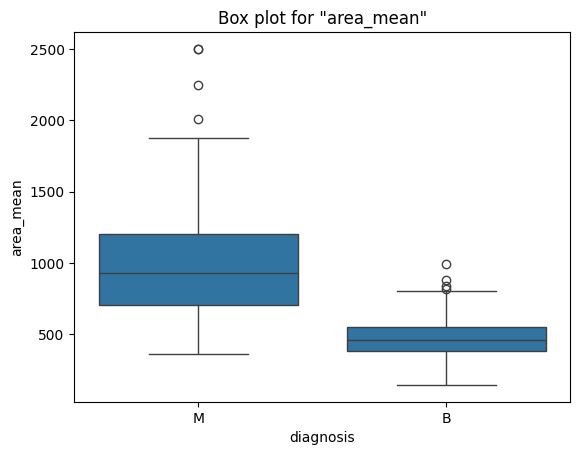

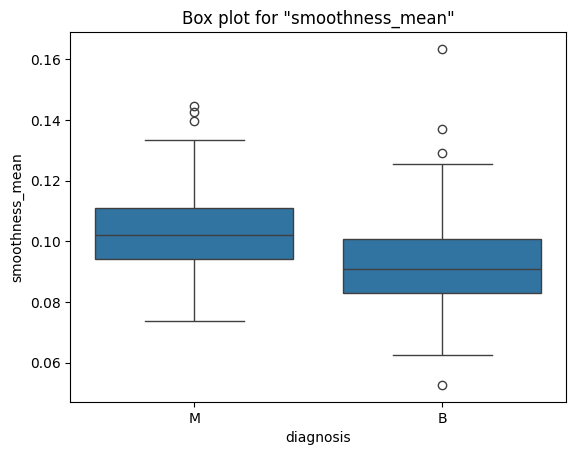

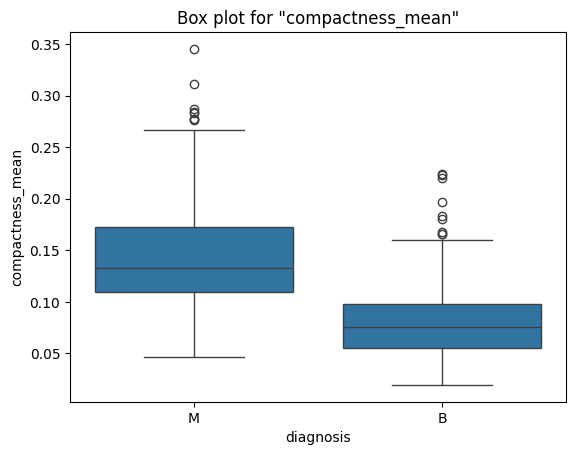

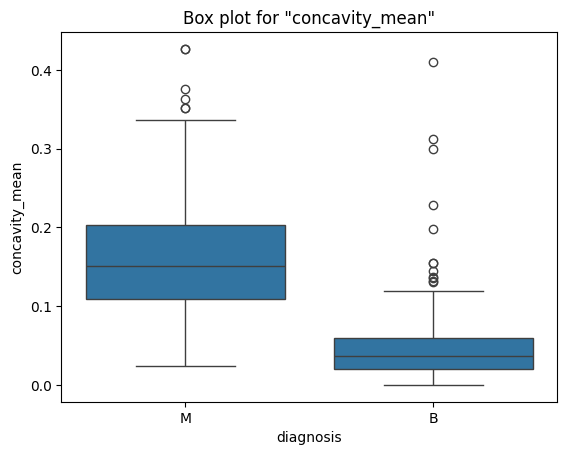

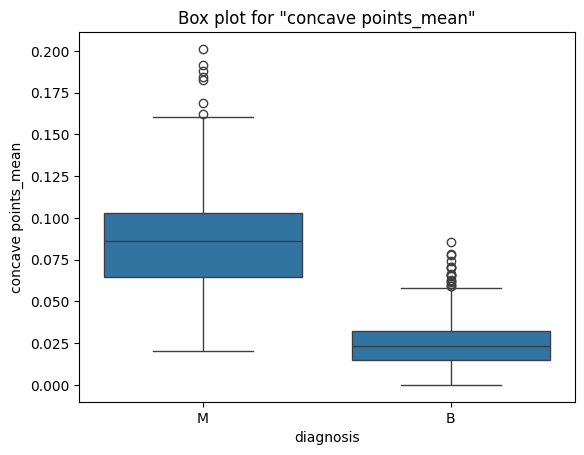

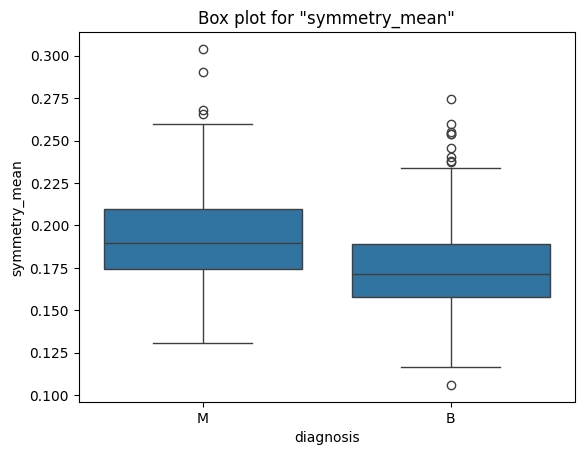

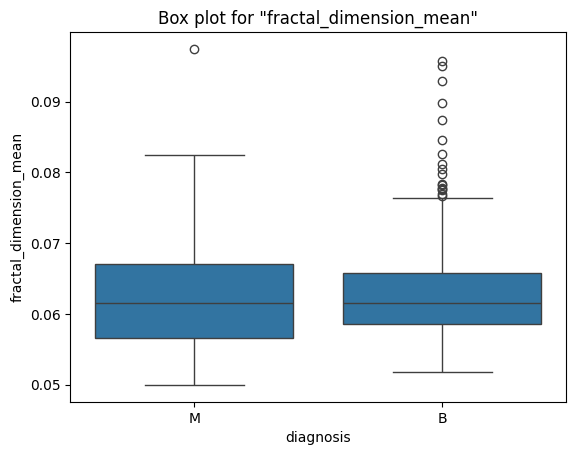

In [81]:
for column in [column for column in correlated_columns.keys() if "mean" in column and not "texture" in column]:
    sns.boxplot(data=data, x="diagnosis", y=column).set_title(f'Box plot for "{column}"')
    plt.show()

Из графиков выше, мы можем наблюдать следующее:
- smoothness, fractal, symmetry пересекаются в большей части, возможно эти параметры строит исключить
- radius, perimeter, area, compactness, concavity, concave являются относительно распределенными параметрами, их включаем в выборку.

Создадим kNN модель и разобьем данные 30/70

In [214]:
include = ["radius", "perimeter", "area", "compactness", "concavity", "concave"]
def is_include(column):
    return any([pat in column for pat in include])

cols = [column for column in correlated_columns if is_include(column)]

X = data[cols]
y = data["diagnosis"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [215]:
scaler = StandardScaler() # стандартизируем данные для приведения к единому масштабу, т.к. в выборку присутствуют различные по масштабу данные
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [259]:
def quality(prediction_y, true_y):
    label = 'M'
    accuracy = accuracy_score(prediction_y, true_y)
    precision = precision_score(prediction_y, true_y, pos_label=label)
    recall = recall_score(prediction_y, true_y, pos_label=label)
    f1 = f1_score(prediction_y, true_y, pos_label=label)
    print("Accuracy:  {:.3f}\nPrecision: {:.3f}\nRecall:    {:.3f}\nF1-score:  {:.3f}".format(
        accuracy, precision, recall, f1
    ))

In [258]:
def train_and_test(knn):
    global preds_test
    global preds
    knn.fit(X_train, y_train)
    preds = knn.predict(X_train)
    preds_test = knn.predict(X_test)
    
def build_roc_curve(knn):
    train_and_test(knn)

    y_scores = knn.predict_proba(X_test)
    fpr, tpr, threshold = roc_curve(y_test, y_scores[:, 1], pos_label='M')

    roc_auc = auc(fpr, tpr)

    plt.title('Receiver Operating Characteristic')
    plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
    plt.legend(loc = 'lower right')
    plt.plot([0, 1], [0, 1],'r--')
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    plt.ylabel('True Positive Rate')
    plt.xlabel('False Positive Rate')
    plt.title('ROC Curve of kNN')
    plt.show()

Посмотрим на значения при стандартных значениях k:

Качество предсказаний по данным для обучения:
Accuracy:  0.947
Precision: 0.906
Recall:    0.951
F1-score:  0.928
Качество предсказаний по данным для валидации:
Accuracy:  0.965
Precision: 0.937
Recall:    0.967
F1-score:  0.952


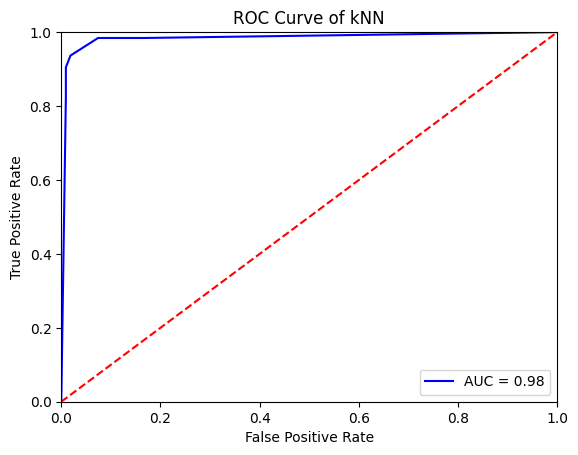

In [261]:
knn = KNeighborsClassifier()
    
train_and_test(knn)

print("Качество предсказаний по данным для обучения:")
quality(preds, y_train)
print("Качество предсказаний по данным для валидации:")
quality(preds_test, y_test)
build_roc_curve(knn)

С помощью кросс-валидации подберем лучшее значение k:

In [231]:
parameters = {'n_neighbors': range(1, 101)}
knn = KNeighborsClassifier()
clf = GridSearchCV(knn, parameters, cv = 5, scoring = 'accuracy')
clf.fit(X, y)
print('Best params: ', clf.best_params_)
print('Best accuracy: ', clf.best_score_)

knn = KNeighborsClassifier(n_neighbors=clf.best_params_["n_neighbors"])
train_and_test(knn)

print("\nКачество предсказаний по данным для обучения:")
quality(preds, y_train)
print("\nКачество предсказаний по данным для валидации:")
quality(preds_test, y_test)

Best params:  {'n_neighbors': 13}
Best accuracy:  0.9332401800962584

Качество предсказаний по данным для обучения:
Accuracy:  0.942
Precision: 0.872
Recall:    0.970
F1-score:  0.919

Качество предсказаний по данным для валидации:
Accuracy:  0.947
Precision: 0.889
Recall:    0.966
F1-score:  0.926


Лучшим значением k для всего набора данных оказалось 13.

Теперь построим ROC кривую для оценки предсказаний модели с лучшим k:

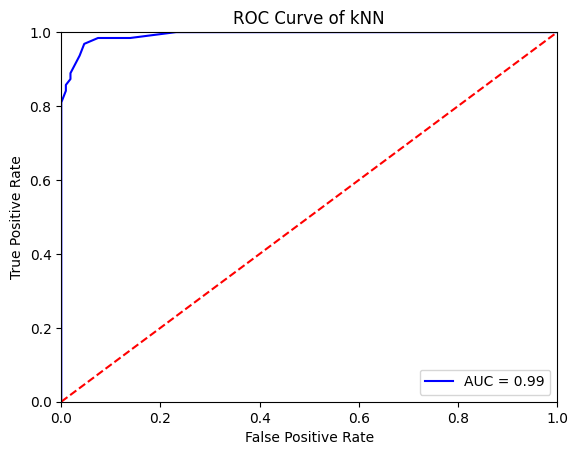

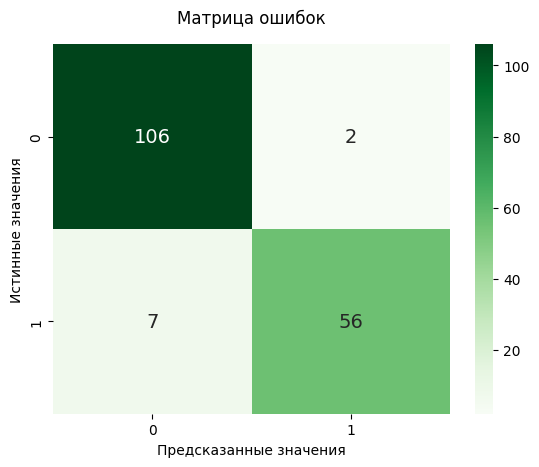

In [270]:
knn = KNeighborsClassifier(n_neighbors=clf.best_params_["n_neighbors"])
build_roc_curve(knn)

cm = confusion_matrix(y_test, preds_test)

sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', annot_kws={'fontsize': 14})
plt.ylabel('Истинные значения')
plt.xlabel('Предсказанные значения')
plt.title('Матрица ошибок', pad=15)
plt.show()